In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
df = pd.read_csv('aqi_data.csv', skipinitialspace=True)
df

,date,pm25,pm10,no2,so2,co
0,2024/8/1,43.0,26.0,73.0,1.0,6.0
1,2024/8/2,45.0,21.0,66.0,1.0,5.0
2,2024/8/3,42.0,22.0,73.0,1.0,4.0
3,2024/8/4,40.0,18.0,96.0,2.0,5.0
4,2024/8/5,37.0,21.0,110.0,1.0,5.0
...,...,...,...,...,...,...
1626,2021/6/28,NaN,13.0,20.0,1.0,4.0
1627,2021/6/29,NaN,28.0,26.0,1.0,5.0
1628,2021/6/30,NaN,31.0,26.0,2.0,4.0
1629,2023/9/26,NaN,NaN,13.0,1.0,8.0


In [64]:
df['date'] = pd.to_datetime(df['date'])

In [65]:
all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = all_dates.difference(df['date'])

print(f"Number of missing dates in sequence: {len(missing_dates)}")
print("First few missing dates:", missing_dates)

Number of missing dates in sequence: 15
First few missing dates: DatetimeIndex(['2020-03-01', '2020-03-23', '2020-03-24', '2020-03-25',
               '2020-03-26', '2020-06-03', '2020-06-04', '2020-06-05',
               '2020-06-06', '2020-06-07', '2020-06-13', '2020-06-14',
               '2020-10-18', '2022-01-07', '2022-01-08'],
              dtype='datetime64[ns]', freq=None)


In [66]:
df_complete = df.set_index('date').reindex(all_dates).rename_axis('date').reset_index()
df_complete

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,NaN,NaN,NaN,NaN
1,2020-02-11,54.0,NaN,NaN,NaN,NaN
2,2020-02-12,167.0,NaN,NaN,NaN,NaN
3,2020-02-13,88.0,NaN,NaN,NaN,NaN
4,2020-02-14,89.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
1641,2024-08-08,44.0,NaN,NaN,NaN,NaN
1642,2024-08-09,43.0,40.0,136.0,2.0,4.0
1643,2024-08-10,50.0,18.0,70.0,1.0,3.0
1644,2024-08-11,41.0,21.0,99.0,1.0,5.0


In [67]:
df_complete.isnull().sum()

date      0
pm25    207
pm10    366
no2     716
so2     301
co      292
dtype: int64

In [68]:
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'co']
df_filled = df_complete.copy()
df_filled[numeric_cols] = df_filled[numeric_cols].interpolate(method='linear')
df_filled = df_filled.bfill().ffill()
df_filled.isnull().sum()

date    0
pm25    0
pm10    0
no2     0
so2     0
co      0
dtype: int64

In [69]:
df_filled

,date,pm25,pm10,no2,so2,co
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000
...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000


# coverting gases to aqi 

In [70]:
def calculate_aqi_p(cp, pollutant):
    # EPA Breakpoints Table
    breakpoints = {
        'pm25': [
            (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
            (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300), (250.5, 500.4, 301, 500)
        ],
        'pm10': [
            (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
            (255, 354, 151, 200), (355, 424, 201, 300), (425, 604, 301, 500)
        ],
        'no2': [
            (0, 53, 0, 50), (54, 100, 51, 100), (101, 360, 101, 150),
            (361, 649, 151, 200), (650, 1249, 201, 300), (1250, 2049, 301, 500)
        ],
        'so2': [
            (0, 35, 0, 50), (36, 75, 51, 100), (76, 185, 101, 150),
            (186, 304, 151, 200), (305, 604, 201, 300), (605, 1004, 301, 500)
        ],
        'co': [
            (0.0, 4.4, 0, 50), (4.5, 9.4, 51, 100), (9.5, 12.4, 101, 150),
            (12.5, 15.4, 151, 200), (15.5, 30.4, 201, 300), (30.5, 50.4, 301, 500)
        ]
    }
    
    if pollutant not in breakpoints: return np.nan
    if pd.isna(cp) or cp < 0: return np.nan

    # Find the correct breakpoint range
    for (bplo, bphi, ilo, ihi) in breakpoints[pollutant]:
        if bplo <= cp <= bphi:
            # The Formula: Ip = ((Ihi - Ilo) / (BPhi - BPlo)) * (Cp - BPlo) + Ilo
            aqi = ((ihi - ilo) / (bphi - bplo)) * (cp - bplo) + ilo
            return round(aqi)
    
    return 500 # Cap at 500 if above range

In [71]:
# Assuming df is your cleaned dataframe from previous steps
# We create new columns for the Index of each pollutant
df_filled['aqi_pm25'] = df_filled['pm25'].apply(lambda x: calculate_aqi_p(x, 'pm25'))
df_filled['aqi_pm10'] = df_filled['pm10'].apply(lambda x: calculate_aqi_p(x, 'pm10'))
df_filled['aqi_no2'] = df_filled['no2'].apply(lambda x: calculate_aqi_p(x, 'no2'))
df_filled['aqi_so2'] = df_filled['so2'].apply(lambda x: calculate_aqi_p(x, 'so2'))
df_filled['aqi_co'] = df_filled['co'].apply(lambda x: calculate_aqi_p(x, 'co'))

# Apply Eq (2): AQI = Max(Indices)
df_filled['final_aqi'] = df_filled[['aqi_pm25', 'aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co']].max(axis=1)

# Categorize the result
def get_status(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "Unhealthy for Sensitive Groups"
    if aqi <= 200: return "Unhealthy"
    return "Very Unhealthy / Hazardous"

df_filled['aqi_status'] = df_filled['final_aqi'].apply(get_status)

print(df_filled[['date', 'final_aqi', 'aqi_status']].head())

        date  final_aqi                      aqi_status
0 2020-02-10         61                        Moderate
1 2020-02-11        147  Unhealthy for Sensitive Groups
2 2020-02-12        217      Very Unhealthy / Hazardous
3 2020-02-13        168                       Unhealthy
4 2020-02-14        168                       Unhealthy


In [72]:
df_filled = df_filled.drop(columns=['aqi_pm25','aqi_pm10', 'aqi_no2', 'aqi_so2', 'aqi_co'])
df_filled

,date,pm25,pm10,no2,so2,co,final_aqi,aqi_status
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000,61,Moderate
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000,147,Unhealthy for Sensitive Groups
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000,217,Very Unhealthy / Hazardous
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy
...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667,122,Unhealthy for Sensitive Groups
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000,119,Unhealthy for Sensitive Groups
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000,137,Unhealthy for Sensitive Groups
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000,115,Unhealthy for Sensitive Groups


In [73]:
numeric_cols.append('final_aqi')

# Visualization of data 

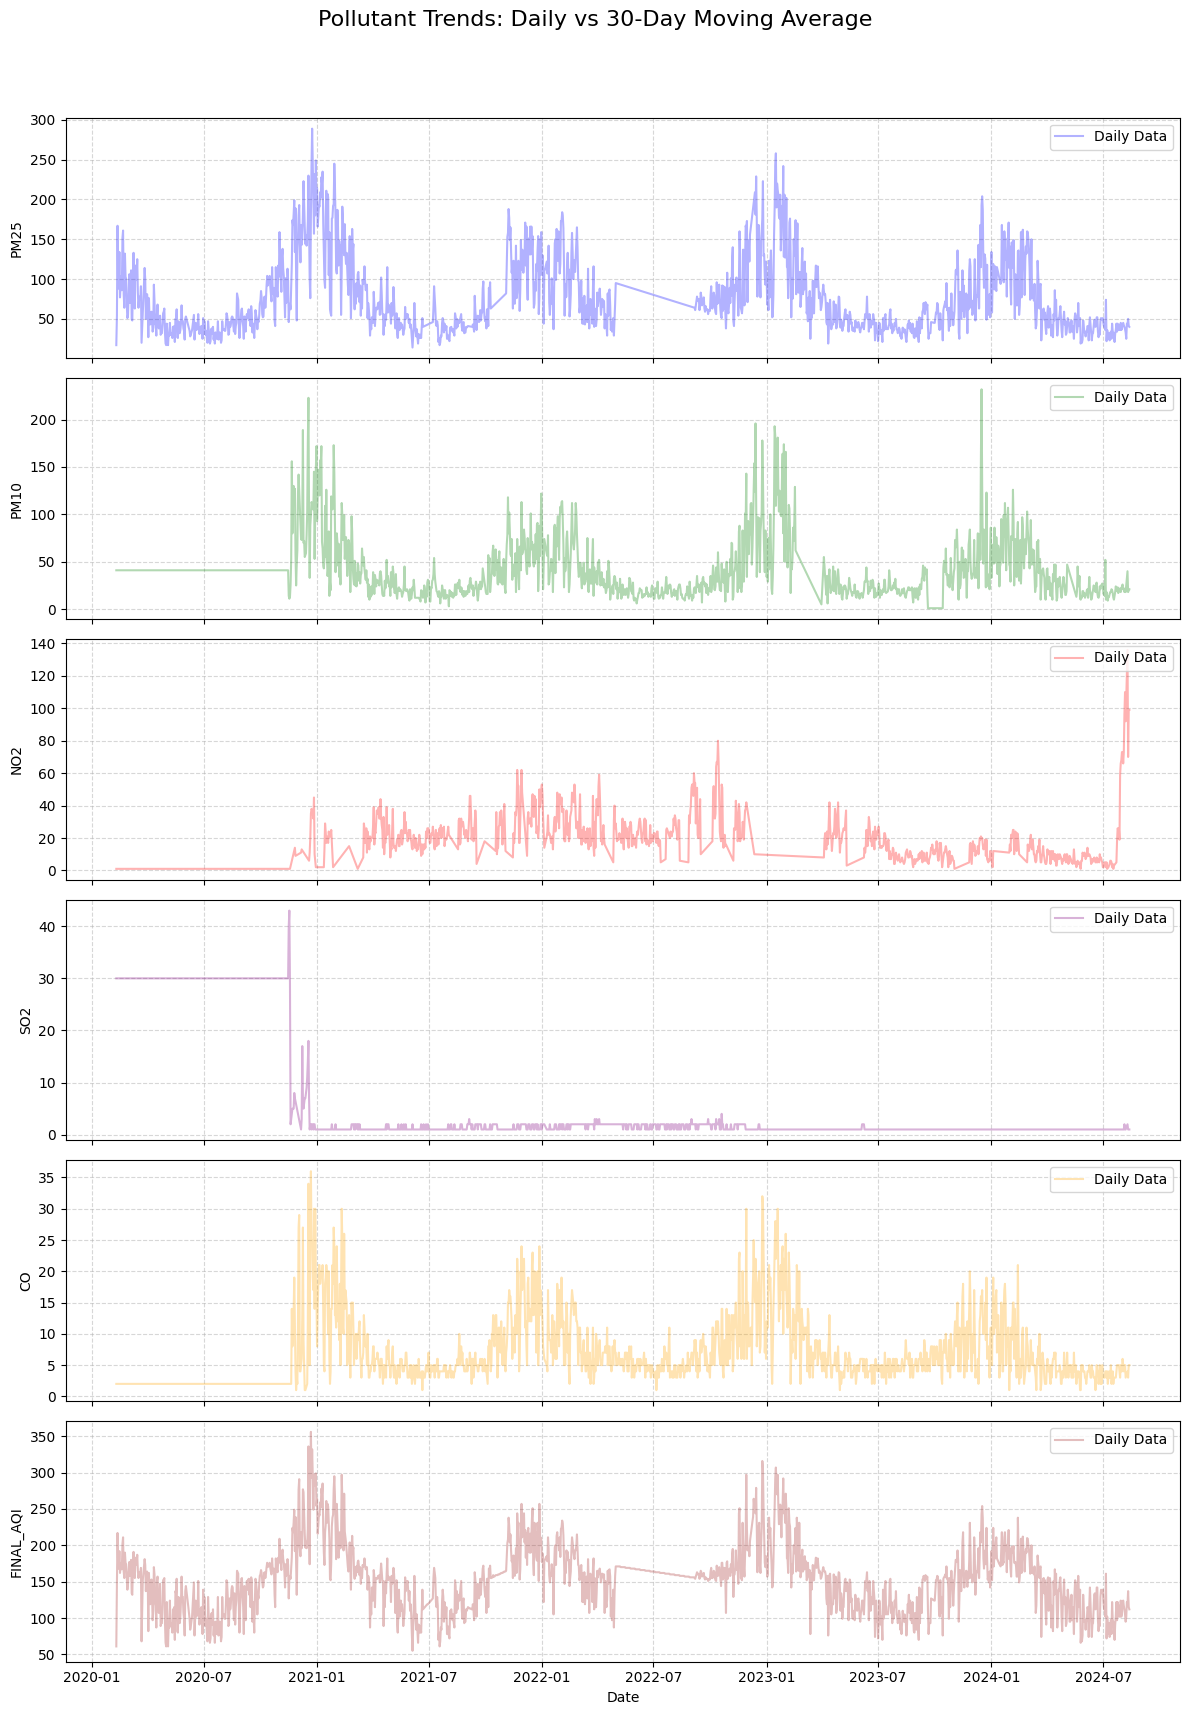

In [74]:
fig, axes = plt.subplots(6, 1, figsize=(12, 18), sharex=True)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

for i, col in enumerate(numeric_cols):
    # Plot the raw daily data (lighter color)
    axes[i].plot(df_filled['date'], df_filled[col], color=colors[i], alpha=0.3, label='Daily Data')
    
    # Plot 30-day moving average (darker color)
    #ma_30 = df_filled[col].rolling(window=30).mean()
    #axes[i].plot(df_filled['date'], ma_30, color=colors[i], alpha=0.9, linewidth=2, label='30-Day MA')
    
    axes[i].set_ylabel(col.upper())
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Date')
plt.suptitle('Pollutant Trends: Daily vs 30-Day Moving Average', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_13017/3843488875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')


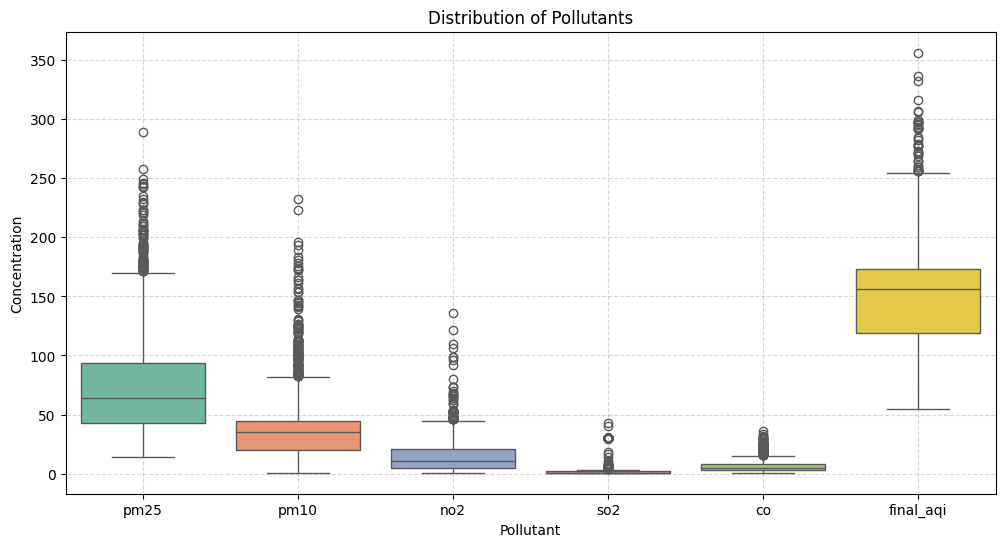

In [75]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 6))
df_plot = df_filled[numeric_cols].melt(var_name='Pollutant', value_name='Concentration')
sns.boxplot(data=df_plot, x='Pollutant', y='Concentration', palette='Set2')
plt.title('Distribution of Pollutants')
plt.ylabel('Concentration')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

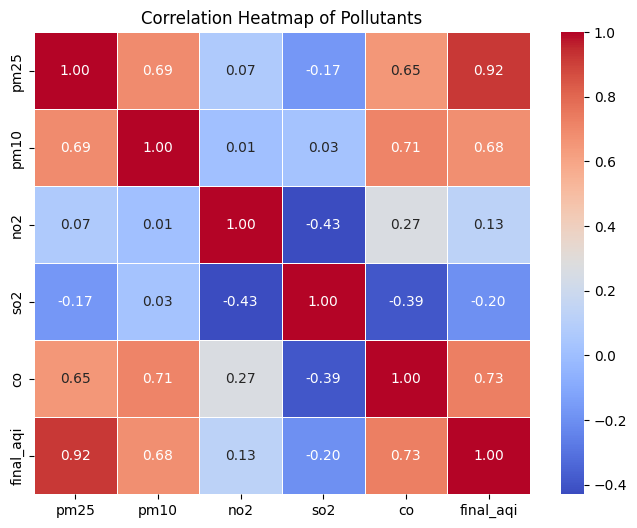

In [76]:

plt.figure(figsize=(8, 6))
correlation = df_filled[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants')
plt.show()

## the higest correlation is between final_aqi and pm25 but i am not going to use final_aqi when i will train model bc it will be my target value (aqi_status)

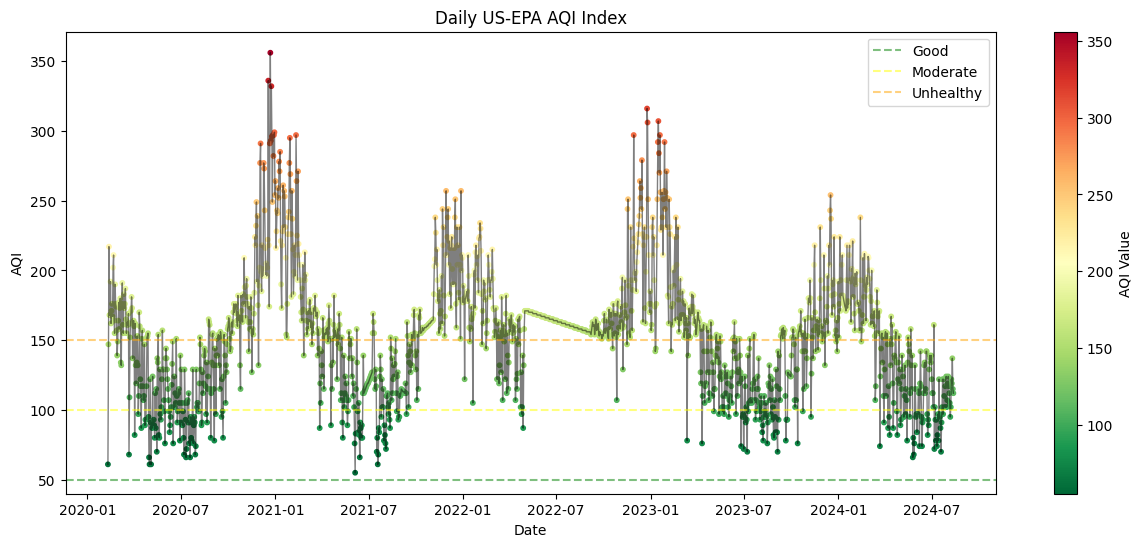

In [77]:
plt.figure(figsize=(15, 6))
plt.plot(df_filled['date'], df_filled['final_aqi'], color='black', linewidth=1, alpha=0.5)
plt.scatter(df_filled['date'], df_filled['final_aqi'], c=df_filled['final_aqi'], cmap='RdYlGn_r', s=10)

plt.axhline(50, color='green', linestyle='--', alpha=0.5, label='Good')
plt.axhline(100, color='yellow', linestyle='--', alpha=0.5, label='Moderate')
plt.axhline(150, color='orange', linestyle='--', alpha=0.5, label='Unhealthy')

plt.title('Daily US-EPA AQI Index')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(loc='upper right')
plt.colorbar(label='AQI Value')
plt.show()

## data for tranig 

In [78]:
df_filled['month'] = df_filled['date'].dt.month
df_filled['dayofweek'] = df_filled['date'].dt.dayofweek
df_filled['is_weekend'] = (df_filled['date'].dt.dayofweek >= 5).astype(int)

In [79]:
df_filled

,date,pm25,pm10,no2,so2,co,final_aqi,aqi_status,month,dayofweek,is_weekend
0,2020-02-10,17.0,41.000000,1.000000,30.000000,2.000000,61,Moderate,2,0,0
1,2020-02-11,54.0,41.000000,1.000000,30.000000,2.000000,147,Unhealthy for Sensitive Groups,2,1,0
2,2020-02-12,167.0,41.000000,1.000000,30.000000,2.000000,217,Very Unhealthy / Hazardous,2,2,0
3,2020-02-13,88.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy,2,3,0
4,2020-02-14,89.0,41.000000,1.000000,30.000000,2.000000,168,Unhealthy,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...
1641,2024-08-08,44.0,32.666667,121.333333,1.666667,3.666667,122,Unhealthy for Sensitive Groups,8,3,0
1642,2024-08-09,43.0,40.000000,136.000000,2.000000,4.000000,119,Unhealthy for Sensitive Groups,8,4,0
1643,2024-08-10,50.0,18.000000,70.000000,1.000000,3.000000,137,Unhealthy for Sensitive Groups,8,5,1
1644,2024-08-11,41.0,21.000000,99.000000,1.000000,5.000000,115,Unhealthy for Sensitive Groups,8,6,1


In [80]:
col_train = ['pm25', 'pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']
X = df_filled[col_train]
y = df_filled['aqi_status']

In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
# Check for any missing values
print("Missing values in X:")
print(X.isnull().sum())
print("\nMissing values in y:")
print(y.isnull().sum())

# Check class distribution
print("\nClass distribution in y:")
print(y.value_counts())

# Check data shapes
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Check feature statistics
print("\nFeature statistics:")
print(X.describe())

Missing values in X:
pm25          0
pm10          0
no2           0
so2           0
co            0
month         0
dayofweek     0
is_weekend    0
dtype: int64

Missing values in y:
0

Class distribution in y:
aqi_status
Unhealthy                         776
Unhealthy for Sensitive Groups    461
Very Unhealthy / Hazardous        205
Moderate                          204
Name: count, dtype: int64

X shape: (1646, 8)
y shape: (1646,)
X_train shape: (1316, 8)
X_test shape: (330, 8)

Feature statistics:
              pm25         pm10          no2          so2           co  \
count  1646.000000  1646.000000  1646.000000  1646.000000  1646.000000   
mean     76.223572    40.272175    14.640340     6.305286     6.728736   
std      44.530912    29.995769    14.188726    10.886165     5.365253   
min      14.000000     1.000000     1.000000     1.000000     1.000000   
25%      43.000000    20.000000     5.000000     1.000000     3.000000   
50%      64.000000    35.333333    11.000000     

# Random Forest

In [88]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Assuming your df_filled is ready (from the notebook)
# Create features and target
df = df_filled.copy()  # your filled dataframe

# Add time features (if not already there)
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

#X = df[['pm25', 'pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']]
X = df[['pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']]
y = df['aqi_status']

# Train-test split (stratified!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 1. RANDOM FOREST WITH CLASS WEIGHTS ===
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    class_weight=class_weight_dict,   # ← This is the key!
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST (Class Weights) ===")
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

# === 2. XGBOOST WITH SAMPLE WEIGHTS ===
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Compute weights
weights = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
sample_weight = np.array([weights[i] for i in y_train_enc])

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train_enc,
    sample_weight=sample_weight,   # ← This is the key for XGBoost!
    eval_set=[(X_test, y_test_enc)],
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

print("\n=== XGBOOST (Sample Weights) ===")
print(classification_report(y_test, y_pred_xgb_labels))

=== RANDOM FOREST (Class Weights) ===
                                precision    recall  f1-score   support

                      Moderate       0.50      0.39      0.44        41
                     Unhealthy       0.74      0.78      0.76       156
Unhealthy for Sensitive Groups       0.51      0.53      0.52        92
    Very Unhealthy / Hazardous       0.84      0.78      0.81        41

                      accuracy                           0.66       330
                     macro avg       0.65      0.62      0.63       330
                  weighted avg       0.66      0.66      0.66       330


Confusion Matrix:
 [[ 16   7  18   0]
 [  1 121  28   6]
 [ 15  28  49   0]
 [  0   8   1  32]]

=== XGBOOST (Sample Weights) ===
                                precision    recall  f1-score   support

                      Moderate       0.40      0.41      0.40        41
                     Unhealthy       0.75      0.69      0.72       156
Unhealthy for Sensitive Groups     

In [89]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# SMOTE only on training set
smote = SMOTE(random_state=42, k_neighbors=3)  # k_neighbors=3 is safe

# For Random Forest
pipeline_rf = Pipeline([
    ('smote', smote),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipeline_rf.fit(X_train, y_train)
print("RF + SMOTE Report")
print(classification_report(y_test, pipeline_rf.predict(X_test)))

# For XGBoost (use encoded labels)
pipeline_xgb = Pipeline([
    ('smote', smote),
    ('xgb', xgb.XGBClassifier(n_estimators=300, random_state=42))
])

pipeline_xgb.fit(X_train, y_train_enc)
y_pred_xgb_pipeline = pipeline_xgb.predict(X_test)
y_pred_xgb_pipeline_labels = le.inverse_transform(y_pred_xgb_pipeline)

print("\nXGBoost + SMOTE Report")
print(classification_report(y_test, y_pred_xgb_pipeline_labels))

RF + SMOTE Report
                                precision    recall  f1-score   support

                      Moderate       0.40      0.46      0.43        41
                     Unhealthy       0.72      0.67      0.69       156
Unhealthy for Sensitive Groups       0.45      0.45      0.45        92
    Very Unhealthy / Hazardous       0.68      0.78      0.73        41

                      accuracy                           0.59       330
                     macro avg       0.56      0.59      0.57       330
                  weighted avg       0.60      0.59      0.60       330


XGBoost + SMOTE Report
                                precision    recall  f1-score   support

                      Moderate       0.41      0.39      0.40        41
                     Unhealthy       0.73      0.68      0.70       156
Unhealthy for Sensitive Groups       0.48      0.53      0.51        92
    Very Unhealthy / Hazardous       0.74      0.78      0.76        41

                 

RF + SMOTE Confusion Matrix:
[[ 19   5  17   0]
 [  5 104  32  15]
 [ 24  27  41   0]
 [  0   8   1  32]]

XGBoost + SMOTE Confusion Matrix:
[[ 16   9  16   0]
 [  3 106  36  11]
 [ 20  23  49   0]
 [  0   8   1  32]]


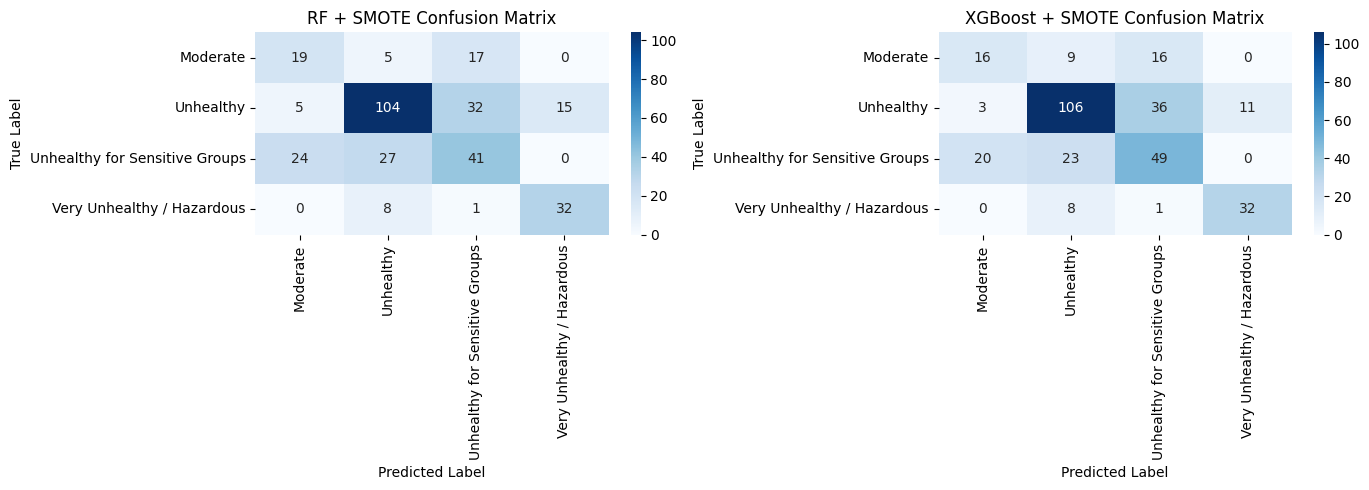

In [90]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix for RF + SMOTE
cm_rf = confusion_matrix(y_test, pipeline_rf.predict(X_test))
print("RF + SMOTE Confusion Matrix:")
print(cm_rf)

# Confusion Matrix for XGBoost + SMOTE
cm_xgb = confusion_matrix(y_test, y_pred_xgb_pipeline_labels)
print("\nXGBoost + SMOTE Confusion Matrix:")
print(cm_xgb)

# Visualize both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF + SMOTE
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('RF + SMOTE Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# XGBoost + SMOTE
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('XGBoost + SMOTE Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_13017/3387197467.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


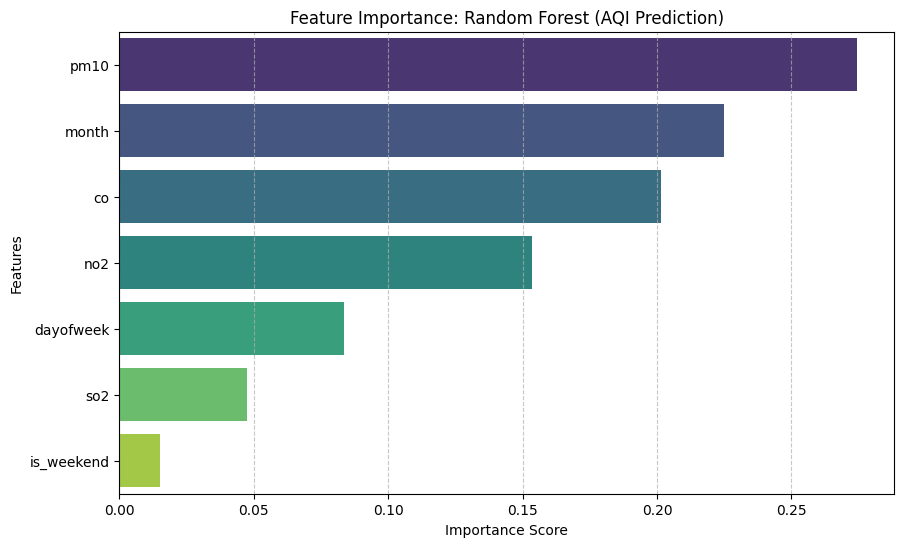


XGBoost Feature Importance:


/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_13017/3387197467.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


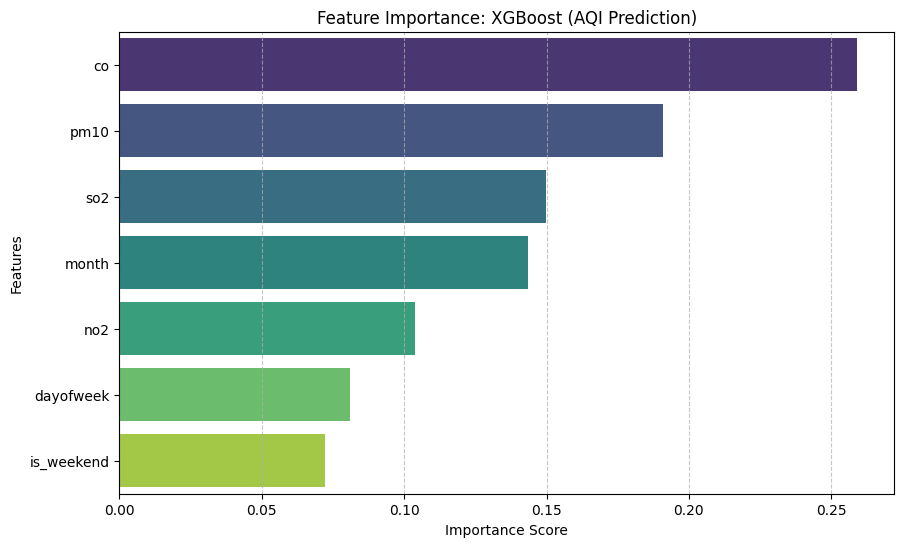

/var/folders/hd/hqx41svd20lcfdp6nt85c0j80000gn/T/ipykernel_13017/3387197467.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')



Random Forest (SMOTE) Feature Importance:


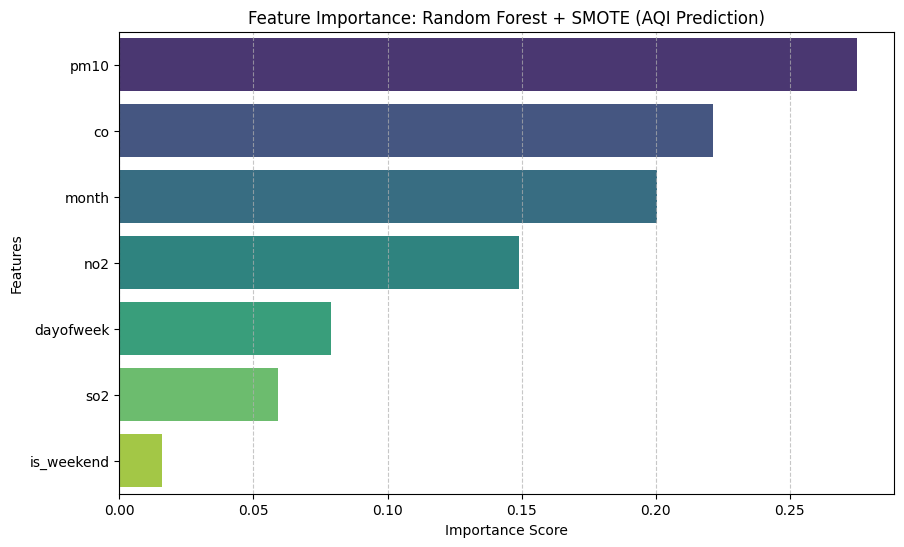

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(model, feature_names, title):
    # Получаем коэффициенты важности
    importances = model.feature_importances_
    
    # Создаем DataFrame для удобства визуализации
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Рисуем график
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    
    plt.title(f'Feature Importance: {title}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Feature columns used in training
feature_cols = ['pm10', 'no2', 'so2', 'co', 'month', 'dayofweek', 'is_weekend']
plot_feature_importance(rf, feature_cols, 'Random Forest (AQI Prediction)')

# Also plot for XGBoost model
print("\nXGBoost Feature Importance:")
plot_feature_importance(xgb_model, feature_cols, 'XGBoost (AQI Prediction)')

# Random Forest from pipeline
print("\nRandom Forest (SMOTE) Feature Importance:")
plot_feature_importance(pipeline_rf.named_steps['rf'], feature_cols, 'Random Forest + SMOTE (AQI Prediction)')